<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ вакансий из HeadHunter
   

In [2]:
!pip install psycopg2-binary

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 2.1 MB/s eta 0:00:02
   ----------- ---------------------------- 0.8/2.8 MB 1.5 MB/s eta 0:00:02
   --------------- ------------------------ 1.0/2.8 MB 1.4 MB/s eta 0:00:02
   ------------------- -------------------- 1.3/2.8 MB 1.4 MB/s eta 0:00:02
   -------------------------- ------------- 1.8/2.8 MB 1.5 MB/s eta 0:00:01
   ------------------------------ --------- 2.1/2.8 MB 1.6 MB/s eta 0:00:01
   -------------------------------------- - 2.6/2.8 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 1.5 MB/s  0:00:02


In [2]:
import pandas as pd
import psycopg2
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# вставьте сюда параметры подключения из юнита 1. Работа с базой данных из Python 

In [47]:
connection.close()
connection = psycopg2.connect(
    dbname='project_sql',
    user='skillfactory',
    host='84.201.134.129',
    password='cCkxxLVrDE8EbvjueeMedPKt',
    port=5432
)

# Юнит 3. Предварительный анализ данных

1. Напишите запрос, который посчитает количество вакансий в нашей базе (вакансии находятся в таблице vacancies). 

In [9]:
# текст запроса
query3_1 = pd.read_sql_query(f'''select count(*) from vacancies''', connection)
query3_1

,count
0,49197


2. Напишите запрос, который посчитает количество работодателей (таблица employers). 

In [10]:
query3_2 = pd.read_sql_query(f'''select count(distinct id) from employers''', connection)
query3_2

,count
0,23501


3. Посчитате с помощью запроса количество регионов (таблица areas).

In [11]:
query3_3 = pd.read_sql_query(f'''select count(*) from areas''', connection)
query3_3

,count
0,1362


4. Посчитате с помощью запроса количество сфер деятельности в базе (таблица industries).

In [12]:
query3_4 = pd.read_sql_query(f'''select count(*) from industries''', connection)
query3_4

,count
0,294


***

# **Выводы по юниту**
Проведён предварительный анализ и ознакомление с данными. Вакансий более, чем в два раза больше, чем работодателей.

# Юнит 4. Детальный анализ вакансий

1. Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).
Отсортируйте по количеству вакансий в порядке убывания.

In [17]:
q4_1 = pd.read_sql_query(f'''select a.name, count(*) from areas a join vacancies v on a.id = v.area_id group by 1 order by 2 desc''', connection)
q4_1

,name,count
0,Москва,5333
1,Санкт-Петербург,2851
2,Минск,2112
3,Новосибирск,2006
4,Алматы,1892
...,...,...
764,Тарко-Сале,1
765,Новоаннинский,1
766,Бирск,1
767,Сасово,1


2. Напишите запрос, чтобы определить у какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой.

In [20]:
querry4_2 = pd.read_sql_query(f'''select count(*) from vacancies where (salary_from > 0 or salary_to > 0)''', connection)
querry4_2

,count
0,24073


3. Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого.

In [21]:
querry4_3 = pd.read_sql_query(f'''select AVG(salary_from)::integer min_avgzp, AVG(salary_to)::integer max_avgzp FROM vacancies''', connection)
querry4_3

,min_avgzp,max_avgzp
0,71065,110537


4. Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Результат отсортируйте по убыванию количества.


In [22]:
querry4_4 = pd.read_sql_query(f'''select schedule, employment, count(*) FROM vacancies group by 1,2 order by 3 desc''', connection)
querry4_4

,schedule,employment,count
0,Полный день,Полная занятость,35367
1,Удаленная работа,Полная занятость,7802
2,Гибкий график,Полная занятость,1593
3,Удаленная работа,Частичная занятость,1312
4,Сменный график,Полная занятость,940
5,Полный день,Стажировка,569
6,Вахтовый метод,Полная занятость,367
7,Полный день,Частичная занятость,347
8,Гибкий график,Частичная занятость,312
9,Полный день,Проектная работа,141


5. Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта. 

In [23]:
querry4_5 = pd.read_sql_query(f'''select experience, count(*) FROM vacancies group by 1 order by 2 asc''', connection)
querry4_5

,experience,count
0,Более 6 лет,1337
1,Нет опыта,7197
2,От 3 до 6 лет,14511
3,От 1 года до 3 лет,26152


***

# Выводы по детальному анализу вакансий
*   В больших по размеру городах больше вакансий.
*   Половина вакансий без указания заработной платы.
*   Подавляющее большинство вакансий - Полная занятость
*   В основном требуются работники с опытом работы От 1 года до 3 лет, далее от От 3 до 6 лет

# Юнит 5. Анализ работодателей

1. Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.

In [27]:
querry5_1 = pd.read_sql_query(f'''(SELECT e.name, count(*) as "1 and 5th place" FROM vacancies v join employers e on e.id = v.employer_id GROUP BY 1 ORDER BY 2 DESC LIMIT 1 OFFSET 0)UNION(SELECT e.name, count(*) FROM vacancies v join employers e on e.id = v.employer_id GROUP BY 1 ORDER BY 2 DESC LIMIT 1 OFFSET 4) order by 2 desc; ''', connection)
querry5_1

,name,1 and 5th place
0,Яндекс,1933
1,Газпром нефть,331


2. Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.
Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей.


In [7]:
querry5_2 = pd.read_sql_query(f'''
    SELECT 
        a.name AS region,
        COALESCE(e.cnt, 0) AS cnt_emp,
        COALESCE(v.cnt, 0) AS cnt_vac
    FROM areas a
    LEFT JOIN (SELECT area, COUNT(*) AS cnt FROM employers GROUP BY area) e 
        ON a.id = e.area
    LEFT JOIN (SELECT area_id, COUNT(*) AS cnt FROM vacancies GROUP BY area_id) v 
        ON a.id = v.area_id
    ORDER BY a.name
''', connection)

querry5_2_ = pd.read_sql_query(f'''(
SELECT a.name as Region, count(*) as Col_Employers_with_no_vacancies
FROM areas a
left join vacancies v on a.id = v.area_id
left join employers e on a.id = e.area
where v.area_id is null
GROUP BY 1
order by 2 desc
LIMIT 1)''', connection)

querry5_2


,region,cnt_emp,cnt_vac
0,Абакан,13,37
1,Абан,0,1
2,Абатское,0,0
3,Абдулино,0,1
4,Абинск,2,6
...,...,...,...
1357,Ярцево,0,2
1358,Ясногорск,0,2
1359,Ясный (Оренбургская область),0,0
1360,Яшкино,0,0


In [8]:
querry5_2_

,region,col_employers_with_no_vacancies
0,Россия,410


3. Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии. Отсортируйте результат по убыванию количества.


In [9]:
querry5_3 = pd.read_sql_query(f'''(
SELECT e.name as employers, count(distinct v.area_id) as cnt_area
FROM employers e
join vacancies v on e.id = v.employer_id
GROUP BY 1
order by 2 desc)''', connection)
querry5_3

,employers,cnt_area
0,Яндекс,181
1,Ростелеком,152
2,Спецремонт,116
3,Поляков Денис Иванович,88
4,ООО ЕФИН,71
...,...,...
14761,UniSol,1
14762,UNISTORY LLC,1
14763,UNIT6,1
14764,United Distribution,1


4. Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности. 

In [11]:
querry5_4 = pd.read_sql_query(f'''(
SELECT count(id)
FROM employers i left join employers_industries e on e.employer_id = i.id
where industry_id is Null
)''', connection)
querry5_4

,count
0,8419


5. Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности. 

In [12]:
querry5_5 = pd.read_sql_query(f'''(
SELECT name, count(distinct industry_id) as cnt
FROM employers_industries e join employers i on e.employer_id = i.id
group by 1
HAVING count(distinct industry_id) = 4
order by 1, 2 desc
limit 1 offset 2
)''', connection)
querry5_5

,name,cnt
0,2ГИС,4


6. С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана Разработка программного обеспечения.


In [13]:
querry5_6 = pd.read_sql_query(f'''(
SELECT count(id)
FROM employers_industries e join industries i on e.industry_id = i.id
where name like 'Разработка программного обеспечени%'
)''', connection)
querry5_6

,count
0,3553


7. Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании. Результат отсортируйте по возрастанию количества.

Список городов-милионников надо взять [отсюда](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8). 

Если возникнут трудности с этим задание посмотрите материалы модуля  PYTHON-17. Как получать данные из веб-источников и API. 

In [27]:
import requests
from bs4 import BeautifulSoup
# Поменял ссылку https://ru.wikipedia.org/wiki/Города-миллионеры_России  , чтобы не было редиректа
url = 'https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

# Поиск таблицы по id="mwGA"
table = soup.find('table', id='mwGA')

cities = []
if table:
    # Находим все строки тела таблицы (tbody)
    tbody = table.find('tbody')
    if tbody:
        rows = tbody.find_all('tr')
    else:
        rows = table.find_all('tr')
    
    for row in rows:
        # Находим все ячейки в строке
        cells = row.find_all('td')
        if len(cells) >= 2:  # Вторая ячейка (индекс 1) содержит город
            city_cell = cells[1]
            city_link = city_cell.find('a')
            if city_link:
                cities.append(city_link.get_text(strip=True))
    
    print(f"Найдено городов: {len(cities)}")
    print(cities)
else:
    print("Таблица с id='mwGA' не найдена")

Найдено городов: 16
['Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург', 'Казань', 'Красноярск', 'Нижний Новгород', 'Челябинск', 'Уфа', 'Краснодар', 'Самара', 'Ростов-на-Дону', 'Омск', 'Воронеж', 'Пермь', 'Волгоград']


In [32]:
cities_sql = ", ".join([f"'{i}'" for i in cities])

q5_7 = pd.read_sql_query(f'''(
(SELECT a.name, count(v.id)
FROM vacancies v
join areas a on v.area_id = a.id
join employers e on e.id = v.employer_id
where e.name = 'Яндекс' and a.name IN ({cities_sql})
group by 1
order by 2 asc)
union all
select 'Total', sum(rr.count) from (SELECT a.name, count(v.id)
FROM vacancies v
join areas a on v.area_id = a.id
join employers e on e.id = v.employer_id
where e.name = 'Яндекс' and a.name IN ({cities_sql})
group by 1
)rr)''', connection)
q5_7

,name,count
0,Омск,21.0
1,Челябинск,22.0
2,Красноярск,23.0
3,Волгоград,24.0
4,Пермь,25.0
5,Казань,25.0
6,Ростов-на-Дону,25.0
7,Уфа,26.0
8,Самара,26.0
9,Краснодар,30.0


***

# Выводы по анализу работодателей
* В Яндекс в 6 раз больше вакансий чем в Газпроме
* В Москве, Санкт-Петербурге, Минске, Новосибирске и Алмаате больше всего работодателей и вакансий.
* Регион Россия реже всего указывают в вакансиях.
* Компании - Яндекс, Ростелеком, Спецремонт и Поляков Денис Иванович больше всего присутствуют в регионах
* У 8419 работодателей не указана сфера деятельности
* Компания 2ГИС находится на 3м месте среди компаний у которых указаны 4 сферы деятельности
* 3553 компаний указали Разработку по в сфере своей деятельности
* Компания Яндекс предствалена в городах миллионниках, общее количество вакансий 485

# Юнит 6. Предметный анализ

1. Сколько вакансий имеет отношение к данным?

Считаем, что вакансия имеет отношение к данным, если в её названии содержатся слова 'data' или 'данн'.

*Подсказка: Обратите внимание, что названия вакансий могут быть написаны в любом регистре.* 


In [33]:
querry6_1 = pd.read_sql_query(f'''(
SELECT count(v.id)
FROM vacancies v
where name ILIKE '%data%' or name ILIKE '%данн%'
)''', connection)
querry6_1 

,count
0,1771


2. Сколько есть подходящих вакансий для начинающего дата-сайентиста? 
Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:
* 'data scientist'
* 'data science'
* 'исследователь данных'
* 'ML' (здесь не нужно брать вакансии по HTML)
* 'machine learning'
* 'машинн%обучен%'

** В следующих заданиях мы продолжим работать с вакансиями по этому условию.*

Считаем вакансиями для специалистов уровня Junior следующие:
* в названии есть слово 'junior' *или*
* требуемый опыт — Нет опыта *или*
* тип трудоустройства — Стажировка.
 

In [34]:
querry6_2 = pd.read_sql_query(f'''(
SELECT count(v.id)
FROM vacancies v
where
(name ilike '%data scientist%'
or name ilike '%data science%'
or name ilike '%исследователь данных%'
or name ilike '%machine learning%'
or name ilike '%машинн%обучен%'
 OR (name ILIKE '%ML%' AND name NOT ILIKE '%HTML%'))
and (name ilike '%junior%' or experience = 'Нет опыта' or employment = 'Стажировка')
)''', connection)
querry6_2

,count
0,51


3. Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

** Критерии для отнесения вакансии к DS указаны в предыдущем задании.*

In [35]:
querry6_3 = pd.read_sql_query(f'''(
SELECT count(id)
FROM vacancies v
where
(name ilike '%data scientist%'
or name ilike '%data science%'
or name ilike '%исследователь данных%'
or name ilike '%machine learning%'
or name ilike '%машинн%обучен%'
 OR (name ILIKE '%ML%' AND name NOT ILIKE '%HTML%'))
and (key_skills ilike '%SQL%' or key_skills ilike '%postrgres%')
)''', connection)
querry6_3

,count
0,229


4. Проверьте, насколько популярен Python в требованиях работодателей к DS.Для этого вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

** Это можно сделать помощью запроса, аналогичного предыдущему.*

In [39]:
querry6_4 = pd.read_sql_query(f'''(
SELECT count(id)
FROM vacancies v
where
(name ilike '%data scientist%'
or name ilike '%data science%'
or name ilike '%исследователь данных%'
or name ilike '%machine learning%'
or name ilike '%машинн%обучен%'
 OR (name ILIKE '%ML%' AND name NOT ILIKE '%HTML%'))
and (key_skills ilike '%python%')
)''', connection)
querry6_4

,count
0,357


5. Сколько ключевых навыков в среднем указывают в вакансиях для DS?
Ответ округлите до двух знаков после точки-разделителя.

In [40]:
querry6_5 = pd.read_sql_query(f'''(
      select round(avg(length(key_skills) - LENGTH(REPLACE(key_skills, '\t', ''))+1),2) as AVG_kl_navikov
      FROM vacancies v
where
(name ilike '%data scientist%'
or name ilike '%data science%'
or name ilike '%исследователь данных%'
or name ilike '%machine learning%'
or name ilike '%машинн%обучен%'
 OR (name LIKE '%ML%' AND name NOT ILIKE '%HTML%'))
  AND key_skills IS NOT NULL
 )''', connection)
querry6_5

,avg_kl_navikov
0,6.41


6. Напишите запрос, позволяющий вычислить, какую зарплату для DS в **среднем** указывают для каждого типа требуемого опыта (уникальное значение из поля *experience*). 

При решении задачи примите во внимание следующее:
1. Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
2. Если заполнены оба поля с зарплатой, то считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, то его и считаем зарплатой по вакансии.
3. Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null). Чтобы избежать этой ситуацию, мы воспользуемся функцией [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull), которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос `select 1 + coalesce(null, 0)`

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа. 

In [41]:
querry6_6 = pd.read_sql_query(f'''(
  SELECT ROUND(AVG(COALESCE((salary_from + salary_to) / 2, salary_from, salary_to)), 0)
FROM vacancies
WHERE (
    name ILIKE '%data scientist%'
    OR name ILIKE '%data science%'
    OR name ILIKE '%исследователь данных%'
    OR name ILIKE '%machine learning%'
    OR name ILIKE '%машинн%обучен%'
    OR (name LIKE '%ML%' AND name NOT ILIKE '%HTML%')
)
AND experience = 'От 3 до 6 лет'
AND key_skills IS NOT NULL
 )''', connection)
querry6_6

,round
0,243115.0


***

# Выводы по предметному анализу

* Проанализировано 49197 вакансий.
* 1771 вакансий связаны с работой с данными.
* Количество вакансий для junior-специалистов очень небольшое от общего числа вакансий и DS (51 вакансия).
* Популярные навыки: SQL (229 вакансий), Python (357 вакансий).
* В среднем в вакансиях указывается боле 6 ключевых навыков.
* Средняя заработная плата составляет 243115 рублей.

# Общий вывод по проекту

## Итоги исследования

Проведённый анализ вакансий в Data-сфере позволяет сформулировать следующие основные выводы:

- **Небольшая доля профильных вакансий** — лишь 3,6% от общего числа предложений связаны с обработкой данных (ключевые слова «data» или «данн»).
- **Дефицит стартовых позиций** — обнаружено всего 51 предложение для junior-специалистов, что может указывать на ограниченный спрос на начинающих кадров.
- **Ключевые навыки** — SQL и Python остаются наиболее востребованными компетенциями в индустрии.
- **Высокая конкуренция** — в среднем на одну вакансию требуется 6 ключевых навыков, что подтверждает жёсткую борьбу за рабочие места.
- **Привлекательный уровень дохода** — средняя заработная плата в сфере Data составляет 243 115 рублей, что является высоким показателем.

## Рекомендации по подготовке данных

Перед началом работы с базой необходимо провести её тщательную очистку и стандартизацию:
- привести данные к единому шаблону;
- устранить дублирующиеся названия вакансий (различия в пробелах, дефисах, регистре, перестановках слов);
- провести синонимизацию — сгруппировать одинаковые по смыслу, но разные по написанию позиции.

## Направления для дальнейших исследований

Анализ можно углубить в следующих областях:

- **Анализ востребованности технологий** — определить, какие инструменты и подходы сейчас наиболее популярны на рынке.
- **Сравнение с другими платформами и странами** — расширить выборку за счёт анализа вакансий с других зарубежных сайтов.

**Дополнительно:** для наглядности ниже представлены графики, иллюстрирующие ключевые тенденции. Также перспективным направлением является построение прогнозных моделей спроса на специалистов и уровня зарплат.

## Обзор самых восстребованных профессий

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Формируем DataFrame с топ-20 наиболее часто встречающихся вакансий
top_vacancies = pd.read_sql_query(
    '''
    SELECT name, COUNT(*) AS vacancy_count
    FROM vacancies
    GROUP BY name
    ORDER BY vacancy_count DESC
    LIMIT 20
    ''',
    connection
)

# Настройка размеров графика
plt.figure(figsize=(12, 8))

# Построение столбчатой диаграммы
barplot = sns.barplot(
    data=top_vacancies,
    x='name',
    y='vacancy_count',
    palette='viridis'
)

# Оформление осей и заголовка
plt.xlabel('Название вакансии', fontsize=12)
plt.ylabel('Количество вакансий', fontsize=12)
plt.title('Топ-20 самых востребованных вакансий', fontsize=14, fontweight='bold')

# Поворот подписей для читаемости
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Добавление значений над столбцами
for patch in barplot.patches:
    height = patch.get_height()
    barplot.text(
        patch.get_x() + patch.get_width() / 2,
        height + 2,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Автоматическая подгонка элементов
plt.tight_layout()

# Отображение графика
plt.show()

DatabaseError: Execution failed on sql: 
    SELECT name, COUNT(*) AS vacancy_count
    FROM vacancies
    GROUP BY name
    ORDER BY vacancy_count DESC
    LIMIT 20
    
server closed the connection unexpectedly
	This probably means the server terminated abnormally
	before or while processing the request.

unable to rollback

Наибольшее количество вакансий приходится на три вспомогательные роли: 

- **системные администраторы** (поддержка инфраструктуры), 
- **разработчики «1С»** (автоматизация учёта), 
- **бизнес-аналитики** (сбор требований и анализ процессов). 

Их востребованность превышает спрос на узкопрофильных Data-специалистов.

## ТОП регионов с самый высокой средней заработной платой

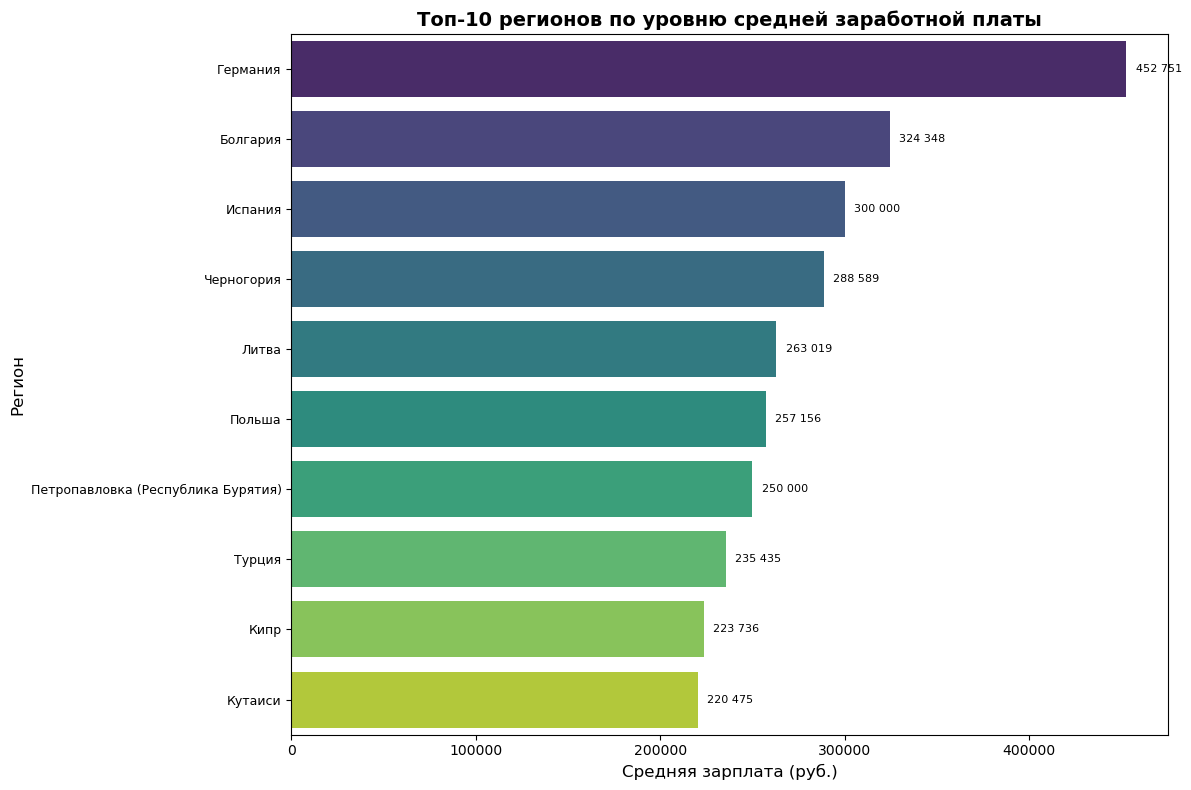

In [49]:
# Запрос для получения средней зарплаты по регионам
salary_by_region = pd.read_sql_query(
    '''
    SELECT
        a.name AS region,
        ROUND(AVG(COALESCE((v.salary_from + v.salary_to) / 2, v.salary_from, v.salary_to)), 0) AS avg_salary
    FROM vacancies v
    JOIN areas a ON v.area_id = a.id
    WHERE v.salary_from IS NOT NULL OR v.salary_to IS NOT NULL
    GROUP BY a.name
    ORDER BY avg_salary DESC
    LIMIT 10
    ''',
    connection
)

# Настройка размера графика
plt.figure(figsize=(12, 8))

# Построение горизонтальной столбчатой диаграммы (лучше читается для длинных названий)
barplot = sns.barplot(
    data=salary_by_region,
    y='region',        # регионы по оси Y
    x='avg_salary',    # зарплата по оси X
    palette='viridis',
    hue='region',
    legend=False
)

# Оформление подписей
plt.xlabel('Средняя зарплата (руб.)', fontsize=12)
plt.ylabel('Регион', fontsize=12)
plt.title('Топ-10 регионов по уровню средней заработной платы', fontsize=14, fontweight='bold')

# Настройка подписей
plt.yticks(fontsize=9)
plt.xticks(fontsize=10)

# Добавление значений в конце каждого бара
for patch in barplot.patches:
    width = patch.get_width()
    if width > 0:
        barplot.text(
            width + 5000,                        # отступ от конца бара
            patch.get_y() + patch.get_height() / 2,
            f'{width:,.0f}'.replace(',', ' '),  # форматирование пробелами
            ha='left',
            va='center',
            fontsize=8
        )

plt.tight_layout()
plt.show()

Кроме Республики Бурятия средняя заработная плата из представленных в выборке вакансий выше в зарубежных странах.

In [ ]:
connection.close()